One liner:
Resolves the domain names to respective IP address
Human readable domain name to machine readable IP address

1. When you type google.com, your browser will looking to its own cache memory, If not found? it will send it to
2. Resolver server, (basically your Internet Service Provider or Cloudflare 1.1.1.1 or Google's 8.8.8.8), so checks its own cache memory, if not found? - It will send it to root server
3. Root systems, (what are they? 13 sets, placed around world by 12 different Orgs, each set has there own unique IPs stored

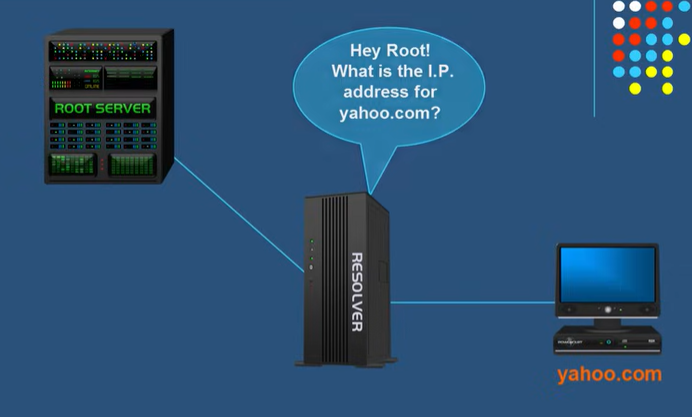

Journey 1: To the root server (root name servers)

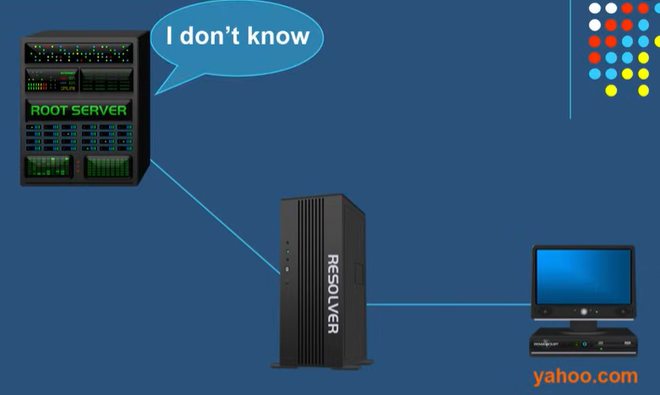
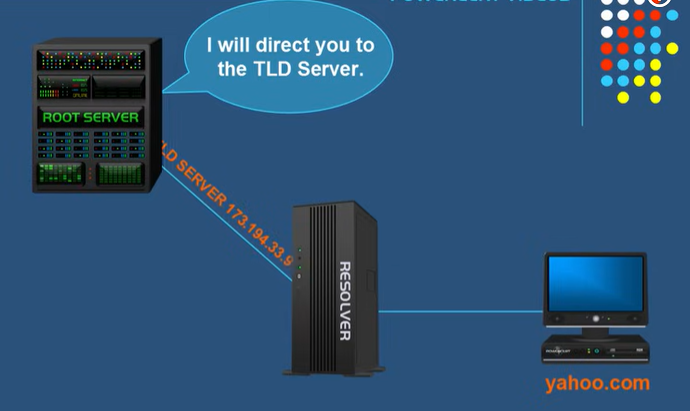
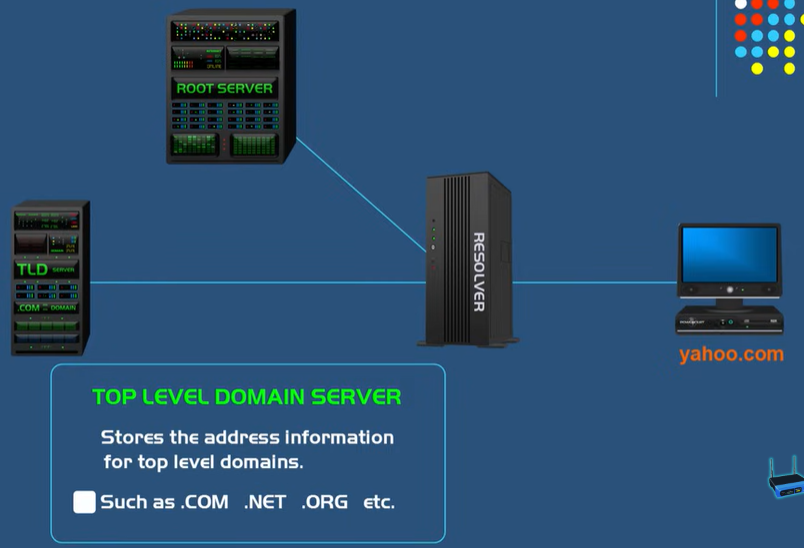
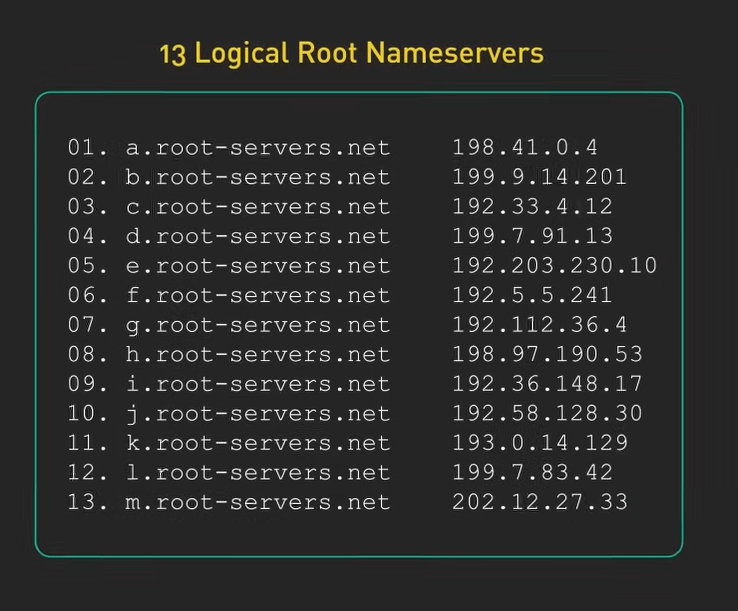
In this journey you get routed to the one closest to you (anycast magic), hhtps://root-servers.org


Journey 2: To the TLD



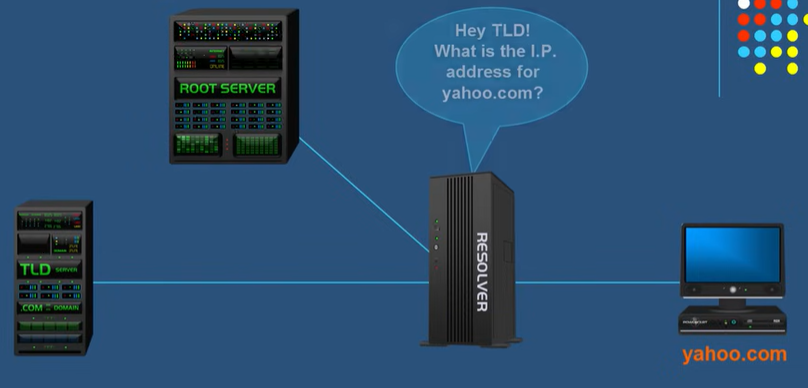
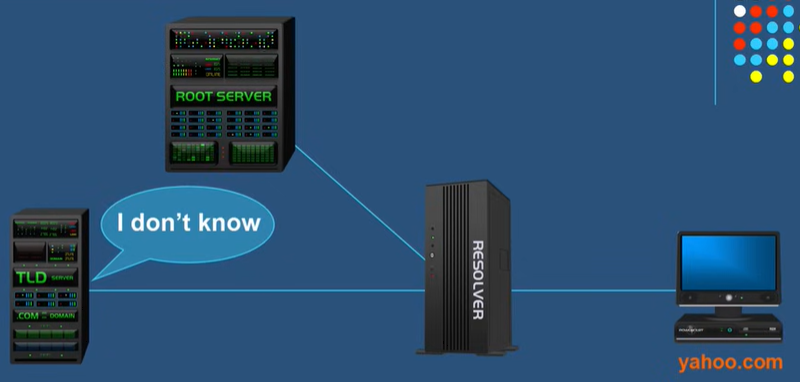
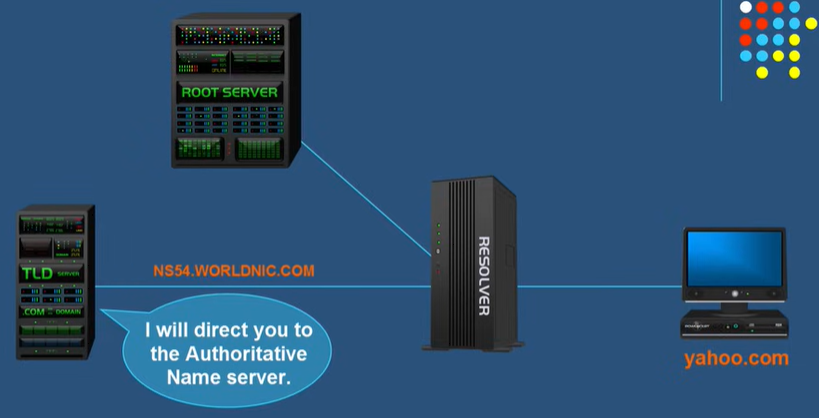

Journey 3: To the Authoritative name servers

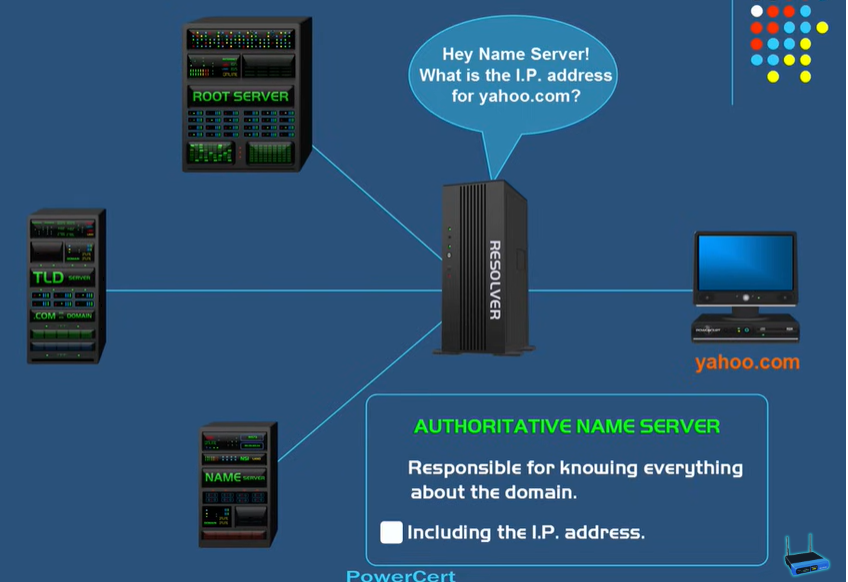
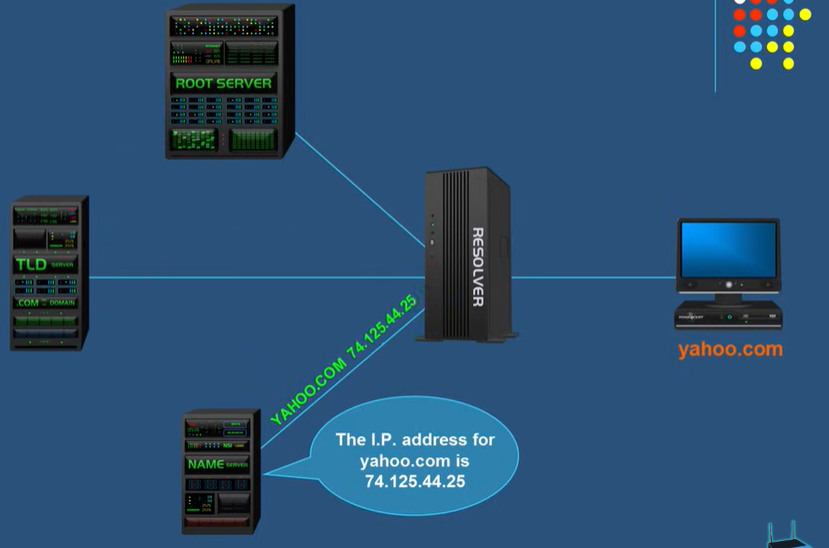

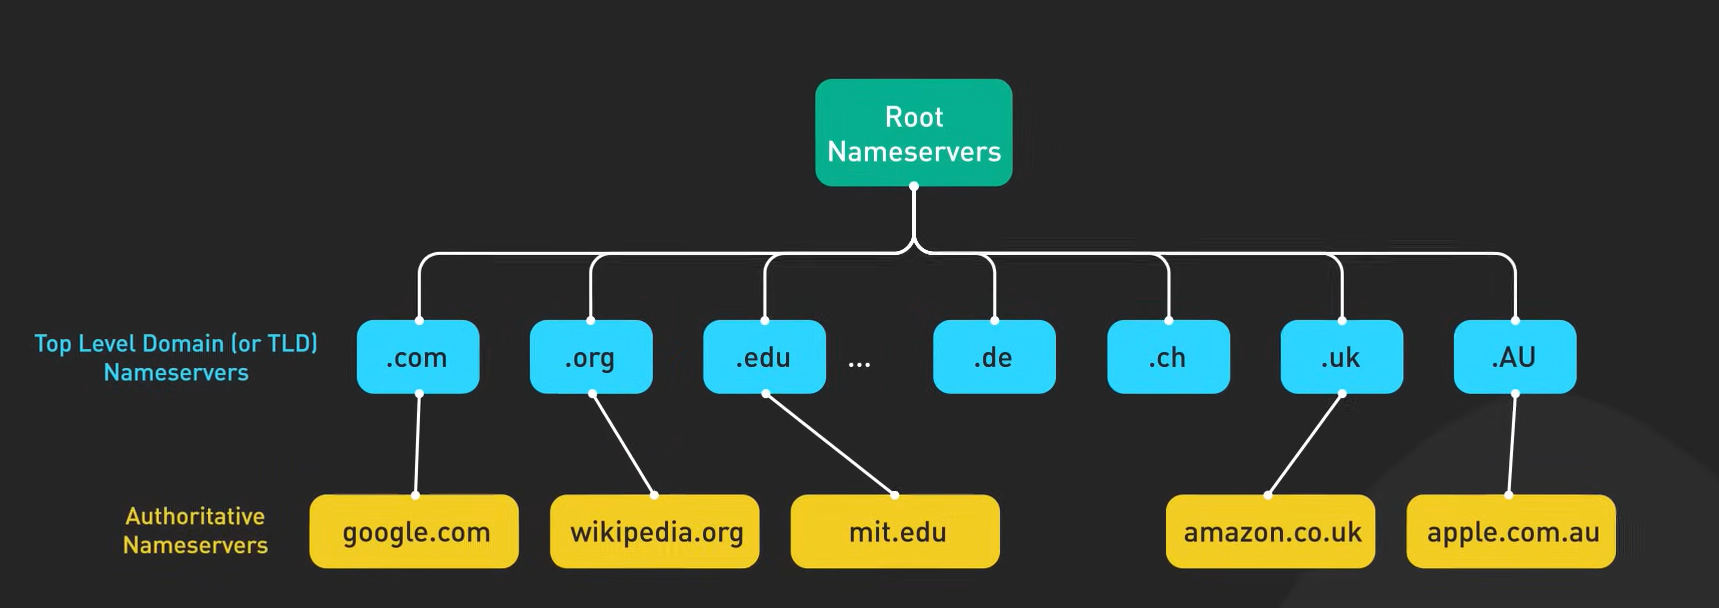

Final:

Resolver caches the retrived info
Your browser catches the retrived info

---
---



more info:

When we register a domain, the  registrar runs the authoritative  
nameservers by default, but  we can change them to others.
Cloud providers like AWS and Cloudflare  run robust authoritative nameservers.
This hierarchical design makes DNS  highly decentralized and robust.

aws, cloudflare has name servers

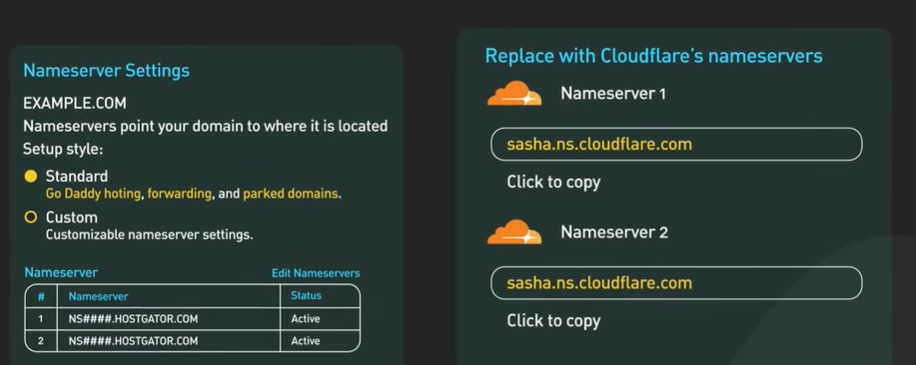

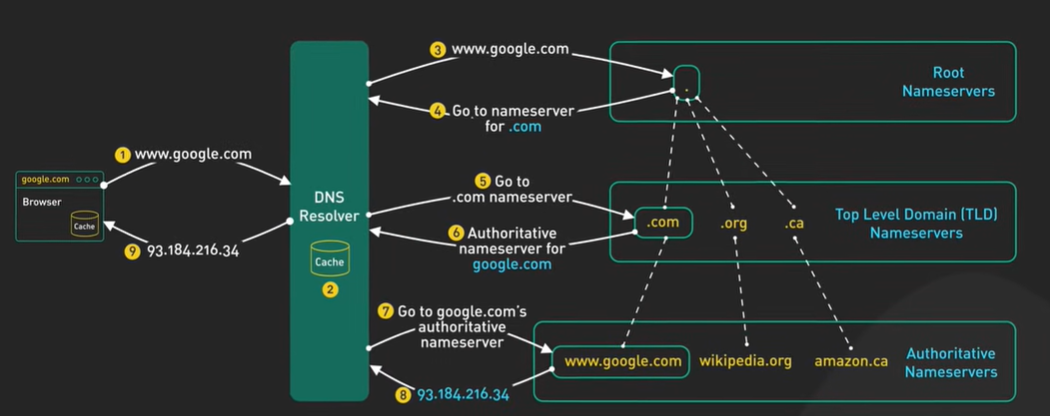

Youtube video: https://www.youtube.com/watch?v=27r4Bzuj5NQ

Gotchas:

DNS Propogation delays vs TTL

You change a website’s IP, but the whole internet does not instantly forget the old one. Many DNS resolvers have already cached the old answer for some time.

## Simple example

Say:

* `api.company.com` currently points to **Old Server IP = 1.1.1.1**
* You want to move traffic to **New Server IP = 2.2.2.2**

And suppose the DNS record currently has:

* **TTL = 24 hours**

TTL means:

> “Resolvers can keep using this DNS answer from cache for up to 24 hours before asking again.”

So if some ISP DNS server looked up `api.company.com` 5 minutes before your change, it may keep sending users to **1.1.1.1** for almost another **24 hours**.

That is why DNS changes can feel “slow.”

---

## What goes wrong in production

If you simply change DNS from:

* `api.company.com -> 1.1.1.1`

to

* `api.company.com -> 2.2.2.2`

then for a while:

* some users go to old server
* some users go to new server

This is normal.

Now imagine you shut down the old server immediately.

Then the users whose DNS cache still points to `1.1.1.1` will fail.

That is the production risk.

---

## Why reduce TTL before the move

Let’s say today is Monday.

You plan to switch traffic on Wednesday.

### Bad way

On Wednesday, you change both:

* TTL from 24h to 60s
* IP from `1.1.1.1` to `2.2.2.2`

This does **not** help much.

Why?

Because many resolvers already cached the old record with the old **24h TTL** before Wednesday.

So they will keep that cached old IP for a long time anyway.

---

### Good way

On Monday, you first change TTL:

* `api.company.com -> 1.1.1.1`
* TTL from **24h** down to **60s**

Then you wait long enough, usually at least the old TTL window.

Now most resolvers refresh and learn:

> “This record should only be cached for 60 seconds.”

Then on Wednesday, you change the IP:

* `api.company.com -> 2.2.2.2`
* TTL still 60s

Now most resolvers re-check quickly, and traffic moves much faster.

---

## Why keep the old server running

Even after you do everything right:

* not all resolvers behave perfectly
* some clients cache weirdly
* some middleboxes ignore TTL
* some apps keep DNS answers longer than they should

So even after the DNS switch, some traffic may still hit:

* `1.1.1.1`

That is why you keep the old server alive for a while.

So during the transition:

* most traffic goes to new server
* leftover traffic still works on old server

Only when traffic to old server becomes very low do you shut it down.

---

## Real-world picture

### Initial state

* `shop.example.com -> 1.1.1.1`
* TTL = 86400 seconds (24h)

### Migration plan

#### Step 1: Lower TTL early

A day or two before cutover:

* `shop.example.com -> 1.1.1.1`
* TTL = 60 seconds

Wait.

This lets caches learn the shorter TTL.

#### Step 2: Cut over

At cutover time:

* `shop.example.com -> 2.2.2.2`
* TTL = 60 seconds

Now many resolvers refresh within about a minute.

#### Step 3: Keep old server alive

Do **not** shut down `1.1.1.1` immediately.

Watch logs/traffic:

* New server gets most traffic
* Old server still gets some stragglers

#### Step 4: Decommission later

Once old traffic is tiny and acceptable, shut down old server.

---

## Easy analogy

Imagine you changed your shop address.

DNS TTL is like telling people:

> “You can keep the old address note for 24 hours before checking again.”

If you suddenly move today, many people still go to the old shop.

Better plan:

1. A day earlier, tell everyone: “Check my address every 1 minute now.”
2. Then change the address.
3. Keep someone at the old shop for a while to redirect late arrivals.

That is exactly what the transcript means.

---

## One interview-style answer

When changing DNS for a live production service, reduce the TTL well before the migration so resolvers stop caching the old answer for too long. Then update the record to the new IP, but keep the old server running during the transition because some resolvers or clients may still use stale DNS and continue sending traffic to the old address.

## One important gotcha

This works best only if:

* old and new servers can both serve the app safely during overlap

If sessions, database writes, uploads, or state are tied only to one server, then DNS cutover needs extra care.

If you want, I can draw this as a **timeline diagram** with “Monday lower TTL -> Wednesday switch IP -> keep old server for 24h” style.


A-->map name to IPV4 
AAAA-->map name to IPV6
CNAME-->mapping one name to another name example: eat.webserver, hungry.webserver both are same

nslookup
dig

note: they may only tests name resolution, not whether the app itself works. So often you pair it with:

curl http://host
dig host
ping host